Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 100      |
|    ep_rew_mean     | -684     |
| time/              |          |
|    fps             | 4475     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 100         |
|    ep_rew_mean          | -929        |
| time/                   |             |
|    fps                  | 3302        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.011095777 |
|    clip_fraction        | 0.0405      |
|    clip_range           | 0.2         |
|    entropy_loss   

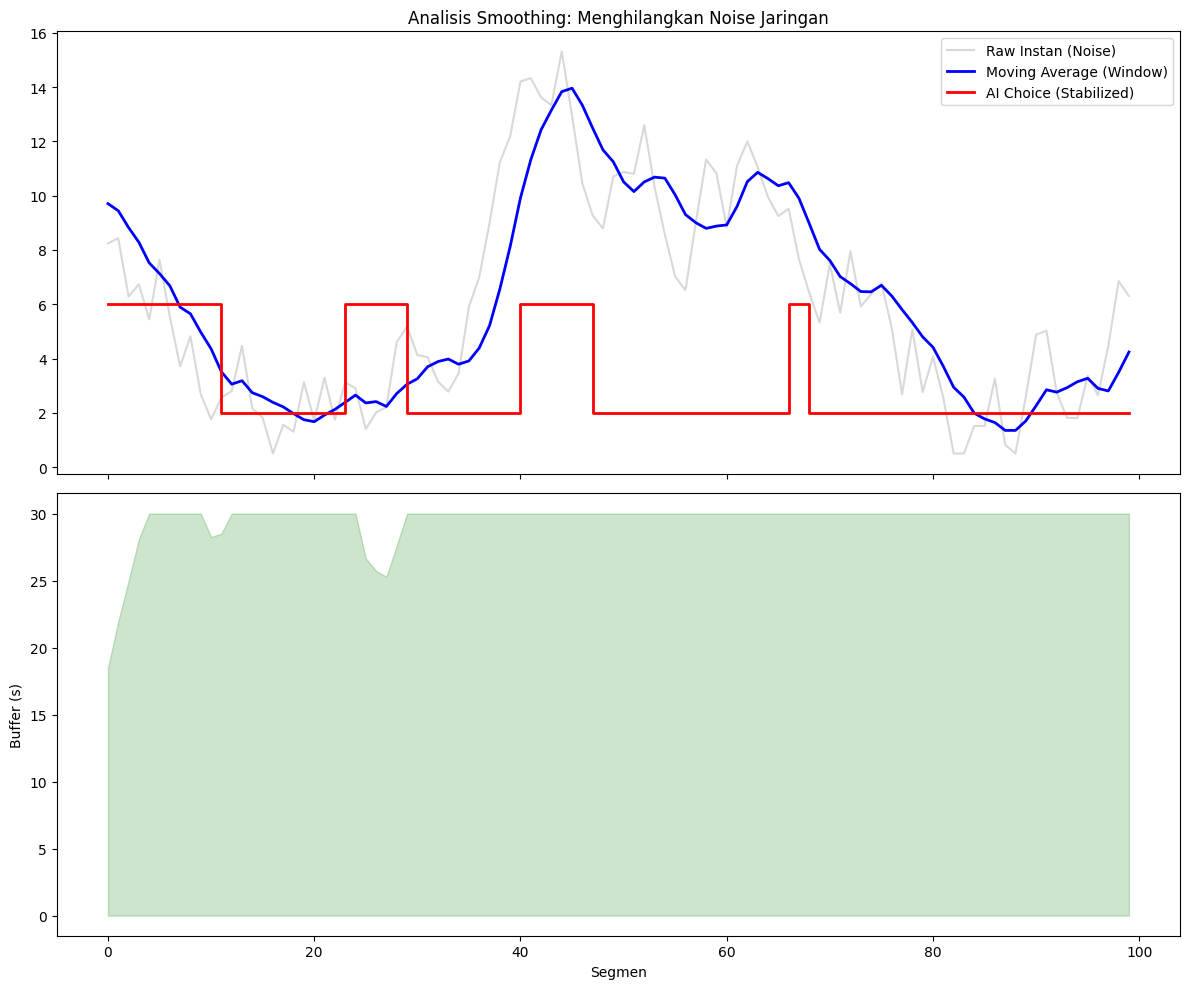

In [2]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from stable_baselines3 import PPO
import matplotlib.pyplot as plt
import pandas as pd
from collections import deque

class SmoothedShakaEnv(gym.Env):
    """
    Simulator Shaka NDN dengan fitur Moving Average Throughput.
    Agen melihat tren rata-rata, bukan angka instan yang bergejolak.
    """
    def __init__(self, window_size=5):
        super(SmoothedShakaEnv, self).__init__()
        self.window_size = window_size
        self.throughput_history = deque(maxlen=window_size)
        self.rtt_history = deque(maxlen=window_size)
        
        # Action & Observation Space (Sama seperti sebelumnya)
        self.action_space = spaces.Discrete(3)
        self.bitrates = [0.5, 2.5, 8.0]
        self.observation_space = spaces.Box(
            low=np.array([0, 0, 0, 0, 0]),
            high=np.array([30, 20, 2, 1000, 100]),
            dtype=np.float32
        )
        self.state = None
        self.max_steps = 100

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # Inisialisasi history dengan nilai awal
        initial_tp = 10.0
        initial_rtt = 50.0
        for _ in range(self.window_size):
            self.throughput_history.append(initial_tp)
            self.rtt_history.append(initial_rtt)
            
        self.state = np.array([15.0, initial_tp, 1.0, initial_rtt, 0.0], dtype=np.float32)
        self.current_step = 0
        return self.state, {}

    def step(self, action):
        buffer, _, last_qual, _, dropped = self.state
        chosen_bitrate = self.bitrates[action]
        
        # 1. Simulasi Realitas (Angka Instan)
        # Kita tetap menggunakan angka instan untuk menghitung durasi download nyata
        raw_throughput = np.clip(self.throughput_history[-1] + np.random.uniform(-2.5, 2.5), 0.5, 20.0)
        raw_rtt = np.clip(self.rtt_history[-1] + np.random.uniform(-15, 15), 10, 500)
        
        seg_dur = 5.0
        download_time = (chosen_bitrate * seg_dur / (raw_throughput + 0.1)) + (raw_rtt / 1000.0)
        
        stalling = max(0, download_time - buffer)
        new_buffer = max(0, buffer - download_time) + seg_dur
        new_buffer = min(new_buffer, 30.0)

        # 2. Update History & Hitung Rata-rata (Smoothing)
        self.throughput_history.append(raw_throughput)
        self.rtt_history.append(raw_rtt)
        
        avg_throughput = sum(self.throughput_history) / len(self.throughput_history)
        avg_rtt = sum(self.rtt_history) / len(self.rtt_history)

        # 3. Logika Reward (Disesuaikan untuk stabilitas)
        reward = chosen_bitrate
        if stalling > 0:
            reward -= 150.0 # Hukuman sangat berat jika sampai macet
        
        # Penalti ganti kualitas tetap ada agar tidak fluktuatif
        reward -= abs(action - last_qual) * 5.0
        
        # Bonus stabilitas jika tetap di kualitas tinggi dan buffer aman
        if action == last_qual and action == 2 and new_buffer > 15:
            reward += 2.0

        # Simpan state (yang dikirim ke Agen adalah nilai RATA-RATA)
        self.state = np.array([new_buffer, avg_throughput, float(action), avg_rtt, 0.0], dtype=np.float32)
        
        self.current_step += 1
        done = self.current_step >= self.max_steps
        
        # Kita juga kirim raw_throughput di 'info' hanya untuk keperluan grafik nanti
        return self.state, reward, done, False, {"raw_tp": raw_throughput}

def run_experiment():
    env = SmoothedShakaEnv(window_size=6) # Rata-rata 6 segmen terakhir (~30 detik tren)
    model = PPO("MlpPolicy", env, verbose=1, learning_rate=0.0003)
    model.learn(total_timesteps=80000)
    
    # Testing
    obs, _ = env.reset()
    history = []
    for i in range(100):
        # Skenario: Internet turun naik tapi banyak noise instan
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _, info = env.step(action)
        
        history.append({
            'Step': i,
            'Raw_TP': info['raw_tp'],
            'Avg_TP': obs[1],
            'Buffer': obs[0],
            'Quality': action
        })

    df = pd.DataFrame(history)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    # Plot 1: Kecepatan Instan vs Rata-rata vs Pilihan AI
    ax1.plot(df['Step'], df['Raw_TP'], label='Raw Instan (Noise)', color='gray', alpha=0.3)
    ax1.plot(df['Step'], df['Avg_TP'], label='Moving Average (Window)', color='blue', linewidth=2)
    ax1.step(df['Step'], df['Quality'] * 4 + 2, label='AI Choice (Stabilized)', color='red', linewidth=2)
    ax1.set_title("Analisis Smoothing: Menghilangkan Noise Jaringan")
    ax1.legend()
    
    # Plot 2: Buffer
    ax2.fill_between(df['Step'], df['Buffer'], color='green', alpha=0.2)
    ax2.set_ylabel("Buffer (s)")
    ax2.set_xlabel("Segmen")
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_experiment()